# Study on % of pid given in educaton

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('educ_uoe_fine06_linear.csv')
df.sample()

,DATAFLOW,LAST UPDATE,freq,unit,isced11,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
1468,ESTAT:EDUC_UOE_FINE06(1.0),07/08/25 23:00:00,Annual,Percentage of gross domestic product (GDP),Primary education,European Union - 27 countries (from 2020),2021,1.09,d,NaN


In [11]:
df["isced11"].value_counts()

isced11
Post-secondary non-tertiary education - general                                              372
Lower secondary education                                                                    364
Tertiary education (levels 5-8)                                                              363
Primary education                                                                            362
Upper secondary education                                                                    362
Upper secondary and post-secondary non-tertiary education (levels 3 and 4)                   359
Pre-primary education                                                                        357
Primary and lower secondary education (levels 1 and 2)                                       357
Post-secondary non-tertiary education - vocational                                           357
Post-secondary non-tertiary education                                                        356
Upper secondary educat

In [14]:
canonical_levels = [
    "Early childhood education",
    "Primary education",
    "Lower secondary education",
    "Upper secondary education",
    "Post-secondary non-tertiary education",
    "Tertiary education (levels 5-8)"
]

df_canonical = df[df["isced11"].isin(canonical_levels)]
total_by_country_year = (
    df_canonical.groupby(["geo", "TIME_PERIOD"])["OBS_VALUE"]
    .sum()
    .reset_index()
    .rename(columns={"OBS_VALUE": "education_pct_gdp_total"})
)

total_by_country_year.sort_values(by='education_pct_gdp_total')

,geo,TIME_PERIOD,education_pct_gdp_total
209,Liechtenstein,2018,0.00
212,Liechtenstein,2021,0.00
211,Liechtenstein,2020,0.00
210,Liechtenstein,2019,0.00
208,Liechtenstein,2017,0.00
...,...,...,...
167,Iceland,2020,8.14
265,Norway,2020,8.24
73,Denmark,2013,8.33
74,Denmark,2014,8.62


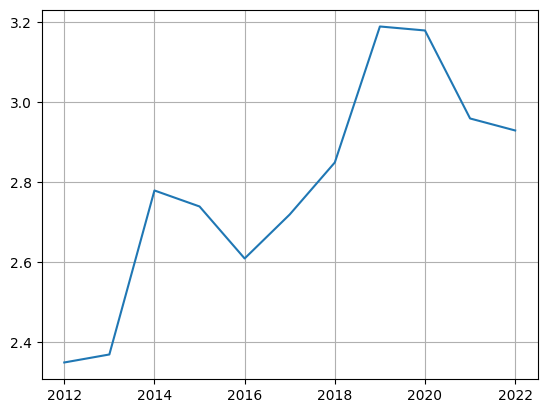

In [19]:
romania = total_by_country_year[total_by_country_year.geo == 'Romania']

plt.plot(romania.TIME_PERIOD, romania.education_pct_gdp_total)
plt.grid()

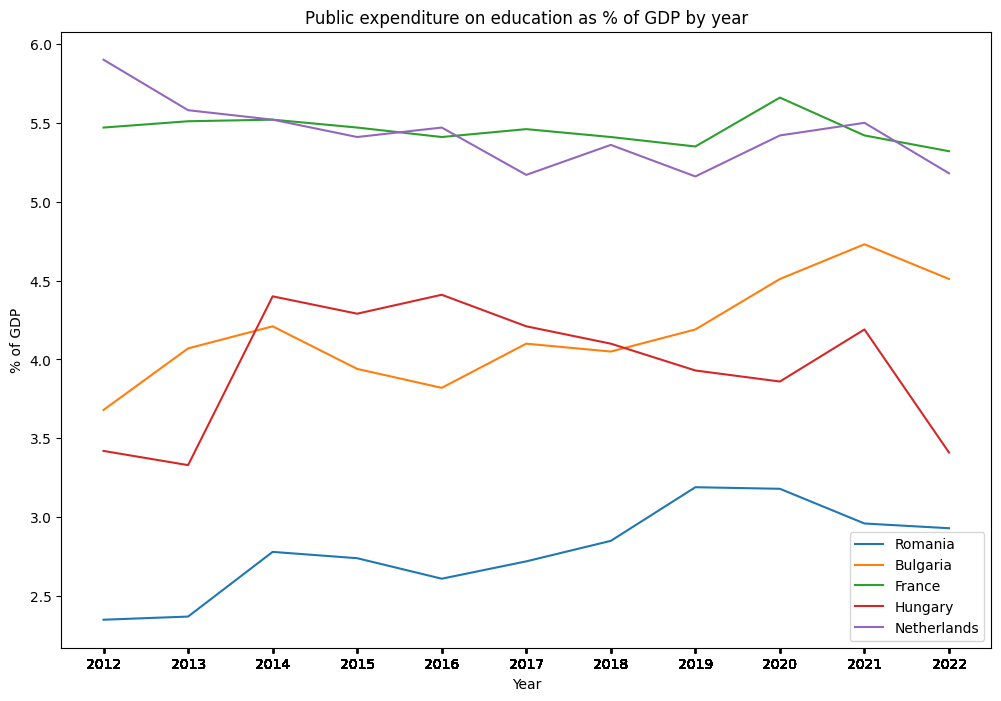

In [ ]:
plt.figure(figsize=(12, 8))

plt.plot(romania.TIME_PERIOD, romania.education_pct_gdp_total, label='Romania')

#plot other contries total_by_country_year

Bulgaria = total_by_country_year[total_by_country_year.geo == 'Bulgaria']
plt.plot(Bulgaria.TIME_PERIOD, Bulgaria.education_pct_gdp_total, label='Bulgaria')

France = total_by_country_year[total_by_country_year.geo == 'France']
plt.plot(France.TIME_PERIOD, France.education_pct_gdp_total, label='France')

Hungary = total_by_country_year[total_by_country_year.geo == 'Hungary']
plt.plot(Hungary.TIME_PERIOD, Hungary.education_pct_gdp_total, label='Hungary')

Netherlands = total_by_country_year[total_by_country_year.geo == 'Netherlands']
plt.plot(Netherlands.TIME_PERIOD, Netherlands.education_pct_gdp_total, label='Netherlands')

plt.xticks(total_by_country_year.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on education as % of GDP by year on sevelar EU countries")
plt.legend()

This dataset goes only untill 2022, so we need to use another one

In [ ]:
# link where to find the dataset: https://ec.europa.eu/eurostat/databrowser/view/gov_10a_exp/default/table

gov_spend = pd.read_csv('gov_10a_exp_linear.csv')
gov_spend.sample()

,DATAFLOW,LAST UPDATE,freq,unit,sector,cofog99,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
5640775,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Million euro,State government,Pre-primary and primary education,Subsidies,Iceland,2001,NaN,m,NaN
